<a href="https://colab.research.google.com/github/Curiouskasu/intro-to-urban-data/blob/main/Scale/S03_GeoPandas_Exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **03 Scale**  GeoPandas Exercise

```
    Class       ARCH 6131 Urban Design Methods / Skills / Tools 1
                Tata Innovation Center
                Fall 2025
                Monday 9:30 AM to 12 PM

    Instructor  Brian Ho
                brian@brian-ho.io
```

This notebook serves as an exercise to practice some of the key technique using GeoPandas for GIS. It assumes you've completed the similar exerciss in the "Basic Python Data Structures" notebook. If you haven't — please complete that beforehand!

## Part 0 A Warm-Up
The following is meant to get you started and set up in this notebook. It also serves as a brief refresher on some key concepts. If you don't have the buildings data, please get it [here](https://github.com/brian-ho/intro-to-urban-data/blob/main/example_data/buildings.geojson).

In [1]:
# Connect to Google Drive
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# Install some additional libraries
!pip install geoplot --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 882.2/882.2 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 58.3 MB/s eta 0:00:00


In [3]:
# Import your dependencies
import geopandas as gpd
import pandas as pd
import geoplot

In [4]:
# Don't forget to re-name the variable below!
BUILDINGS_FILE_PATH = "/content/drive/MyDrive/Fall 2025/URBAN DATA/SCALE/example files/buildings.geojson"

In [13]:
# Load in the data
buildings_gdf = gpd.read_file(BUILDINGS_FILE_PATH)
nyc_boroughs_gdf = gpd.read_file(geoplot.datasets.get_path("nyc_boroughs"))

In [12]:
# You can quickly take a look at the data using GeoDataFrame.head()
nyc_boroughs_gdf.head()

,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
0,5,Staten Island,330385.03697,1.623853e+09,"MULTIPOLYGON (((-74.05051 40.56642, -74.05047 ..."
1,4,Queens,861038.47930,3.049947e+09,"MULTIPOLYGON (((-73.83668 40.59495, -73.83678 ..."
2,3,Brooklyn,726568.94634,1.959432e+09,"MULTIPOLYGON (((-73.86706 40.58209, -73.86769 ..."
3,1,Manhattan,358532.95642,6.364422e+08,"MULTIPOLYGON (((-74.01093 40.68449, -74.01193 ..."
4,2,Bronx,464517.89055,1.186804e+09,"MULTIPOLYGON (((-73.89681 40.79581, -73.89694 ..."


Total area of geometries in each borough:
BoroName
Bronx            1.186804e+09
Brooklyn         1.959432e+09
Manhattan        6.364422e+08
Queens           3.049947e+09
Staten Island    1.623853e+09
Name: Shape_Area, dtype: float64


In [9]:
# You can also iterate over the rows in a loop using GeoDataFrame.iterrows()
for i, row in nyc_boroughs_gdf.iterrows():
    print(f"The {i}th row is {row['BoroName']}")

The 0th row is Staten Island
The 1th row is Queens
The 2th row is Brooklyn
The 3th row is Manhattan
The 4th row is Bronx


In [16]:
# As a reminder, when you load data into a GeoDataFrame you can get a number of helpful attributes.
# For example, you can get the number of columns and rows.
print(f'There are {len(nyc_boroughs_gdf)} rows in the "nyc_boroughs_gdf" dataset.')
print(
    f"There are {len(nyc_boroughs_gdf.columns)} columns: {nyc_boroughs_gdf.columns.tolist()}"
)
print(f"This means it has a shape of {nyc_boroughs_gdf.shape}")

There are 5 rows in the "nyc_boroughs_gdf" dataset.
There are 5 columns: ['BoroCode', 'BoroName', 'Shape_Leng', 'Shape_Area', 'geometry']
This means it has a shape of (5, 5)


The max is: 3049947236.73
The min is: 636442167.467
The mean is: 1691295807.1454
The median is: 1623853249.91


<Axes: ylabel='Frequency'>

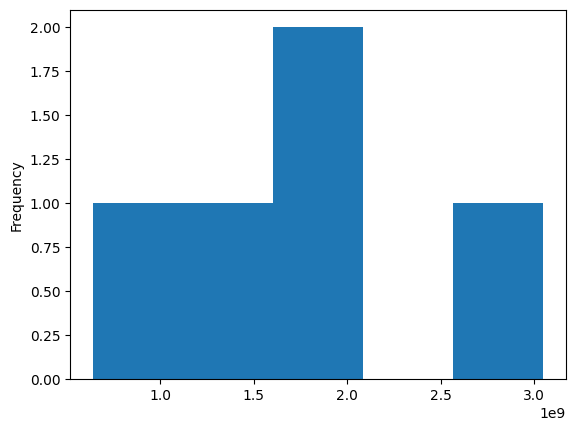

In [17]:
# We can get some statistical summaries
print(f"The max is: {nyc_boroughs_gdf['Shape_Area'].max()}")
print(f"The min is: {nyc_boroughs_gdf['Shape_Area'].min()}")
print(f"The mean is: {nyc_boroughs_gdf['Shape_Area'].mean()}")
print(f"The median is: {nyc_boroughs_gdf['Shape_Area'].median()}")

# We can get some basic plots too!
nyc_boroughs_gdf["Shape_Area"].plot.hist(bins=5)

<Axes: xlabel='Shape_Area', ylabel='Shape_Leng'>

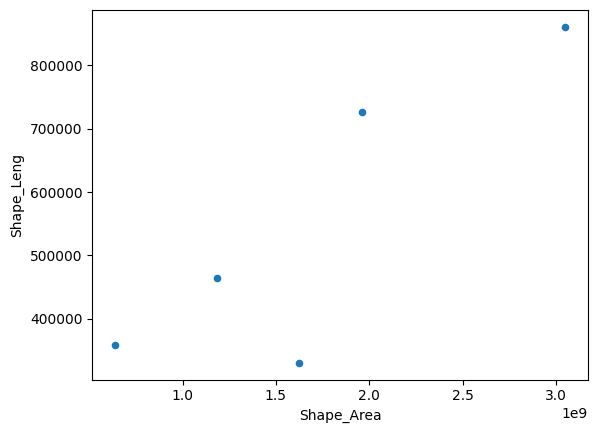

In [18]:
# We can get some other plots with multiple columns
nyc_boroughs_gdf.plot.scatter("Shape_Area", "Shape_Leng")

<Axes: >

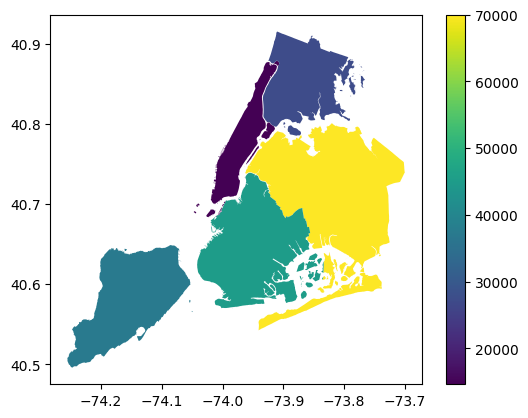

In [19]:
# You can even add columns and plot them as choropleth maps.
nyc_boroughs_gdf["Shape_Area_Acres"] = (
    nyc_boroughs_gdf["Shape_Area"] / 43_560
)  # square feet per acre
nyc_boroughs_gdf.plot(column="Shape_Area_Acres", legend=True)

In [15]:
# You can also do basic filters using the [] syntax
b_boroughs_gdf = nyc_boroughs_gdf[nyc_boroughs_gdf["BoroName"].str.startswith("B")]
b_boroughs_gdf

,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
2,3,Brooklyn,726568.94634,1.959432e+09,"MULTIPOLYGON (((-73.86706 40.58209, -73.86769 ..."
4,2,Bronx,464517.89055,1.186804e+09,"MULTIPOLYGON (((-73.89681 40.79581, -73.89694 ..."


In [14]:
# Or more complex ones
# First, we'll convert to a local projection https://epsg.io/2263
nyc_boroughs_feet_gdf = nyc_boroughs_gdf.to_crs(2263)
nyc_boroughs_feet_gdf[nyc_boroughs_feet_gdf["geometry"].area > 2_000_000_000]

,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
1,4,Queens,861038.4793,3.049947e+09,"MULTIPOLYGON (((1029606.077 156073.814, 102957..."


In [32]:
# You can also use functions that operate on each value in a column, using apply()
def make_short_name(borough_name):
    return borough_name[:4]


# This applies the function make_short_name() to each value in the "BoroName" column
nyc_boroughs_gdf["Short_Name"] = nyc_boroughs_gdf["BoroName"].apply(make_short_name)
nyc_boroughs_gdf[["BoroName", "Short_Name"]]

,BoroName,Short_Name
0,Staten Island,Stat
1,Queens,Quee
2,Brooklyn,Broo
3,Manhattan,Manh
4,Bronx,Bron


In [28]:
# You can also use functions that operate on entire rows and across multiple columns
def make_long_name(borough):
    return f"{borough['BoroName']} - Code {borough['BoroCode']}"


# This applies the function make_long_name() to each row
# The axis=1 argument meands the apply() function operates on row
nyc_boroughs_gdf["Long_Name"] = nyc_boroughs_gdf.apply(make_long_name, axis=1)
nyc_boroughs_gdf[["BoroName", "BoroCode", "Long_Name"]]

,BoroName,BoroCode,Long_Name
0,Staten Island,5,Staten Island - Code 5
1,Queens,4,Queens - Code 4
2,Brooklyn,3,Brooklyn - Code 3
3,Manhattan,1,Manhattan - Code 1
4,Bronx,2,Bronx - Code 2


<Axes: >

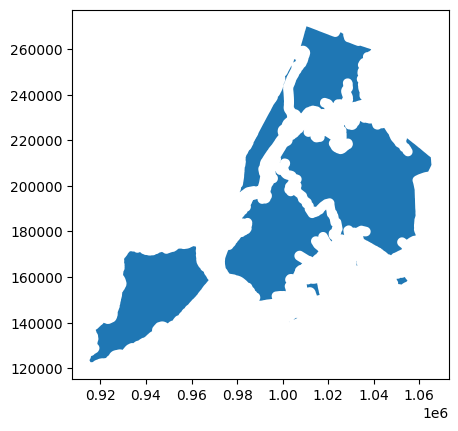

In [29]:
# There are a number of geometry operations you can do too!
def make_smaller(geom):
    return geom.buffer(-2000)


# First, let's make a copy of the GeoDataFrame
nyc_boroughs_in_feet_gdf = nyc_boroughs_gdf.copy()

# Again, we'll project it to a local CRS
nyc_boroughs_in_feet_gdf = nyc_boroughs_in_feet_gdf.to_crs(2263)

# Then apply our function to the "geommetry" column
nyc_boroughs_in_feet_gdf["geometry"] = nyc_boroughs_in_feet_gdf["geometry"].apply(
    make_smaller
)
nyc_boroughs_in_feet_gdf.plot()

In [33]:
# We can check the number of each value
nyc_boroughs_gdf["Short_Name"].value_counts()

,count
Short_Name,
Stat,1
Quee,1
Broo,1
Manh,1
Bron,1


In [34]:
# Finally, you can filter out specific row(s)
bronx = nyc_boroughs_gdf[nyc_boroughs_gdf["BoroName"] == "Bronx"]
bronx

,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry,Shape_Area_Acres,Short_Name,Long_Name
4,2,Bronx,464517.89055,1.186804e+09,"MULTIPOLYGON (((-73.89681 40.79581, -73.89694 ...",27245.274215,Bron,Bronx - Code 2


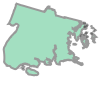

In [35]:
# And get specific values from them
bronx_geom = bronx["geometry"].values[0]
bronx_geom

In [43]:
t

<Axes: >

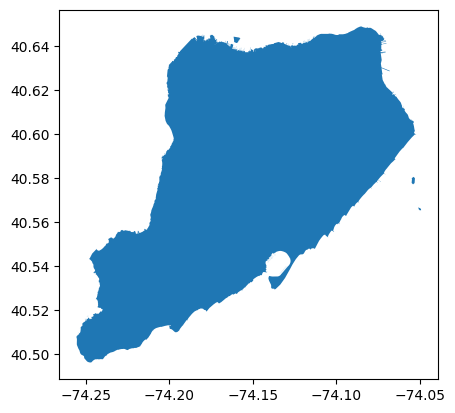

In [44]:
# A spatial join should gives interesting results — why would this include Queens and Manhattan?
join_gdf = nyc_boroughs_gdf.sjoin(bronx)
join_gdf.plot()

<Axes: >

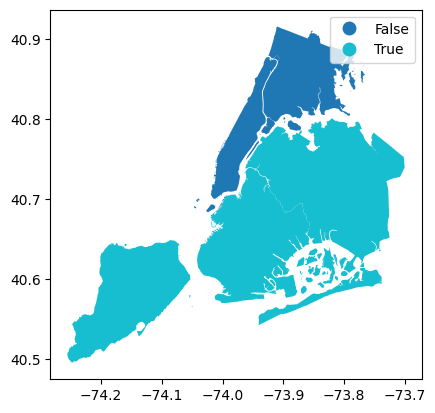

In [45]:
# ... and which also enables more interesting analysis
def is_larger_than_bronx(borough):
    return borough["geometry"].area > bronx_geom.area


nyc_boroughs_gdf["Bigger_Than_Bronx"] = nyc_boroughs_gdf.apply(
    is_larger_than_bronx, axis=1
)
nyc_boroughs_gdf.plot(column="Bigger_Than_Bronx", legend=True)

## Part 1: The Basics
Complete the following using the `buildings_gdf` dataset. If you don't have the buildings data, please get it [here](https://github.com/brian-ho/intro-to-urban-data/blob/main/example_data/buildings.geojson).

1. How many buildings are in the `buildings_gdf` dataset?

In [47]:
buildings_gdf=gpd.read_file("/content/drive/MyDrive/Fall 2025/URBAN DATA/SCALE/example files/buildings.geojson")
print(f"There are {len(buildings_gdf)} buildings in the dataset")

There are 11868 buildings in the dataset



2. How many columns are there in the `buildings_gdf` dataset?

In [49]:
print(f"There are {len(buildings_gdf.columns)} columns in the dataset")

There are 8 columns in the dataset


3.  Print all the names of the columns in `buildings_gdf`.

In [51]:
buildings_gdf.head()

,base_bbl,cnstrct_yr,doitt_id,groundelev,heightroof,mpluto_bbl,name,geometry
0,1003060013,1900.0,512541.0,39.0,73.130000,1003060013,None,"POLYGON ((-73.99304 40.71761, -73.99301 40.717..."
1,3024050006,1899.0,663480.0,50.0,35.566775,3024050006,None,"POLYGON ((-73.96309 40.71421, -73.96312 40.714..."
2,3021370021,1920.0,244666.0,44.0,37.003867,3021370021,None,"POLYGON ((-73.96417 40.70941, -73.96417 40.709..."
3,1003760007,1900.0,555544.0,8.0,54.299846,1003760007,None,"POLYGON ((-73.97852 40.72384, -73.97856 40.723..."
4,3023570024,1960.0,840996.0,26.0,26.390000,3023570024,None,"POLYGON ((-73.96369 40.71727, -73.96382 40.717..."


In [63]:
print(buildings_gdf.columns.tolist())

['base_bbl', 'cnstrct_yr', 'doitt_id', 'groundelev', 'heightroof', 'mpluto_bbl', 'name', 'geometry']


## Part 2: Summaries
4. Compute the  height of each building in `buildings_gdf`, adding it as a column to the dataframe.

In [55]:
average_heightroof_gdf= buildings_gdf['heightroof'].mean()
print (f"The average height of buildings is {(average_heightroof_gdf)} ft.")

The average height of buildings is 68.10383113248281 ft.


5. Find the height of the tallest building in `buildings_gdf`.

In [56]:
tallest_heightroof_gdf= buildings_gdf['heightroof'].max()
print (f"The tallest buildings is {(tallest_heightroof_gdf)} ft.")

The tallest buildings is 1408.377901 ft.


6. Find the height of the building with the lowest ground elevation in `buildings_gdf`.

In [58]:
lowest_groundelev_gdf= buildings_gdf['groundelev'].min()
print (f"The shortest Ground evelation of a building is {(shortest_heightroof_gdf)} ft.")

The shortest Ground evelation of a building is 6.42919425 ft.


7. Estimate the volume of each buliding as its height times its area. You'll need to conver your buildings to be in feet, not degrees. Add the volume as a column to the `buildings_gdf`.

In [64]:
# Convert buildings_gdf to a projected CRS in feet (using EPSG:2263 for NYC)
buildings_gdf_feet = buildings_gdf.to_crs(2263)

buildings_gdf_feet['area_sq_feet'] = buildings_gdf_feet.geometry.area

# Estimate the volume as height times area
# Assuming 'heightroof' is already in feet based on previous calculations
buildings_gdf_feet['volume_cubic_feet'] = buildings_gdf_feet['heightroof'] * buildings_gdf_feet['area_sq_feet']

# Display the first few rows with the new columns
display(buildings_gdf_feet[['heightroof', 'area_sq_feet', 'volume_cubic_feet']].head())

,heightroof,area_sq_feet,volume_cubic_feet
0,73.130000,2751.575466,201222.713853
1,35.566775,784.775976,27911.950401
2,37.003867,1453.741744,53794.065453
3,54.299846,3230.691350,175426.043088
4,26.390000,1446.704883,38178.541854


8. Find the mean (average) and median volume of all buildings.

In [67]:
# Find the mean (average) and median volume of all buildings. Erstwhile mistake- using buildings_gdf rather than buildings_gdf_feet
mean_volume = buildings_gdf_feet['volume_cubic_feet'].mean()
median_volume = buildings_gdf_feet['volume_cubic_feet'].median()

print(f"The mean volume of buildings is {mean_volume:.2f} cu.ft.")
print(f"The median volume of buildings is {median_volume:.2f} cu.ft.")

The mean volume of buildings is 567986.46 cu.ft.
The median volume of buildings is 104363.11 cu.ft.


## Part 3: Operations
9. Extract the geometry for the borough of Manhattan from `nyc_boroughs_gdf`.

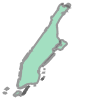

In [68]:
manhattan_geometry = nyc_boroughs_gdf[nyc_boroughs_gdf['BoroName'] == 'Manhattan']['geometry'].iloc[0]
display(manhattan_geometry)

10. Buffer the geometry in by 100 feet — so that it is smaller. What is its area?

In [72]:
# Ensure the Manhattan geometry is in a projected CRS with units in feet (EPSG:2263)
# Need to create a GeoSeries from the geometry to use .to_crs()
manhattan_geometry_feet = gpd.GeoSeries([manhattan_geometry], crs=nyc_boroughs_gdf.crs).to_crs(2263).iloc[0]

# Buffer the geometry by -100 feet to make it smaller
buffered_manhattan_geometry = manhattan_geometry_feet.buffer(-100)

# Calculate the area of the buffered geometry
buffered_area = buffered_manhattan_geometry.area

print(f"The area of the buffered Manhattan geometry is {buffered_area:.2f} square feet.")

The area of the buffered Manhattan geometry is 607256989.24 square feet.


11. Using the buffered (smaller) geometry for Manhattan, create a GeoDataFrame with a single row.

In [74]:
# Create a GeoDataFrame with the buffered Manhattan geometry
buffered_manhattan_gdf = gpd.GeoDataFrame({
    'BoroCode': [nyc_boroughs_gdf[nyc_boroughs_gdf['BoroName'] == 'Manhattan']['BoroCode'].iloc[0]],
    'BoroName': ['Manhattan (Buffered)'],
    'geometry': [buffered_manhattan_geometry]
}, crs="EPSG:2263") # Specify the CRS here

display(buffered_manhattan_gdf)

,BoroCode,BoroName,geometry
0,1,Manhattan (Buffered),"MULTIPOLYGON (((1007699.206 258383.679, 100786..."


12. Create a spatial join to extract all the buildings in `buildings_gdf` that are in your buffered (smaller) geometry for Manhattan.

13. Plot the histogram for the height of all the buildings in your buffered (smaller) geometry for Manhattan.

14. Plot a scatterplot with the ground elevation as the X-axis and the total height as the Y-axis.

That's it! Save the resulting GeoJSON to your Google Drive to submit later.

## Optional Challenge!
If you'd like to preview some of next week's material, try using `apply` functions. Can you write and apply a function that takes a building and checks if:
- Its ground elevation is higher than 10 feet
- Its total height is more than 50 feet
- Its footprint area is larger than 1,000 square feet
- It is _not_ contained in Manhattan

Now that you have that function, apply it to the `buildings_gdf` dataframe. Can you filter the results to just those that match?

If you made it this far, save a separate GeoJSON to your Google Drive to submit later!